# 🌐 LG ThinQ Multi-Community Data Crawling & Analysis Notebook (Non-Reddit)

이 노트북은 Reddit 이외의 복수 커뮤니티(Hacker News, GitHub, Home Assistant Forum, SmartThings Community, Twitter/X, (선택) YouTube 등)에서 LG ThinQ 관련 공개 텍스트를 수집·표준화·분석하는 파이프라인을 제공합니다.

아래 27개 섹션을 순차 구현합니다. 필요한 API Key / Token을 `.env`에 배치하세요.


## 1. Targets & Ethical / Legal Considerations

대상 소스 목록 (초기 버전):
- Hacker News (Algolia Search API, 공개 JSON)
- GitHub (REST Search API /search/repositories, /search/issues) - 인증 토큰 권장
- Home Assistant Forum (Discourse 기반 JSON endpoints)
- SmartThings Community (Discourse 기반 JSON endpoints)
- Twitter/X (snscrape 비공식. 서비스 정책 최신 확인 필요)
- LG Official Community Forum (HTML 파싱: robots.txt 허용 범위 내)
- (Optional) YouTube Data API (videos + commentThreads)

주요 준수 항목:
- robots.txt 파악 후 금지 구역 미수집
- Rate limit: 각 소스별 최소 0.8~1.2초 sleep (또는 header rate tracking)
- 개인정보: 개인식별정보(이메일/전화/IP) 필터링 (현재는 공개 일반 텍스트만 수집 가정)
- 재배포: 데이터는 내부 분석 목적 (외부 재배포 시 원문 플랫폼 정책 재확인)
- 로그 & 캐시: IP 차단 방지 위해 캐싱 활성화, 백오프 적용

진행 플래그:
```python
FETCH_HN = True
FETCH_GITHUB = True
FETCH_HOMEASSIST = True
FETCH_SMARTTHINGS = True
FETCH_TWITTER = True  # snscrape 설치 필요
FETCH_LG_FORUM = True
FETCH_YOUTUBE = False  # API Key 필요
```

In [1]:
# 2. Install & Import
import sys, subprocess, importlib, os
BASE_PACKAGES = [
    'requests','httpx','requests_cache','beautifulsoup4','pandas','numpy','tqdm','python-dotenv',
    'langdetect','nltk','konlpy','textblob','scikit-learn','wordcloud','matplotlib','seaborn','networkx'
]
OPTIONAL = ['snscrape','sentence-transformers']
for pkg in BASE_PACKAGES + OPTIONAL:
    try:
        if pkg=='scikit-learn': importlib.import_module('sklearn')
        else: importlib.import_module(pkg.replace('-','_'))
    except ImportError:
        try:
            print('[INSTALL]', pkg)
            subprocess.check_call([sys.executable,'-m','pip','install',pkg])
        except Exception as e:
            print('[WARN] Install fail', pkg, e)

import pandas as pd, numpy as np, time, math, json, re, hashlib, itertools, datetime as dt
from pathlib import Path
from tqdm import tqdm
import requests, httpx, requests_cache
from bs4 import BeautifulSoup
from dotenv import load_dotenv
from langdetect import detect, DetectorFactory
DetectorFactory.seed = 0
from textblob import TextBlob
from wordcloud import WordCloud
import seaborn as sns, matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
import networkx as nx

print('Imports complete.')

[INSTALL] beautifulsoup4
[INSTALL] python-dotenv
[INSTALL] python-dotenv
[INSTALL] sentence-transformers
[INSTALL] sentence-transformers
Imports complete.
Imports complete.


In [2]:
# 3. Configuration & Secrets (.env)
load_dotenv()
DATA_DIR = Path('data/thinq_multisource'); DATA_DIR.mkdir(parents=True, exist_ok=True)
RAW_DIR = DATA_DIR/'raw'; RAW_DIR.mkdir(exist_ok=True)
PROC_DIR = DATA_DIR/'processed'; PROC_DIR.mkdir(exist_ok=True)
ART_DIR = DATA_DIR/'artifacts'; ART_DIR.mkdir(exist_ok=True)

GITHUB_TOKEN = os.getenv('GITHUB_TOKEN')
YOUTUBE_API_KEY = os.getenv('YOUTUBE_API_KEY')
PROXY = os.getenv('HTTP_PROXY') or os.getenv('HTTPS_PROXY')
USER_AGENTS = [
    'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 Chrome/124 Safari/537.36',
    'Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/605.1.15 Version/15.1 Safari/605.1.15'
]

if not GITHUB_TOKEN:
    print('[WARN] No GITHUB_TOKEN set -> lower rate limit (60/hr)')
if not YOUTUBE_API_KEY:
    print('[INFO] No YOUTUBE_API_KEY; YouTube section will be skipped unless enabled manually.')

# Fetch flags
FETCH_HN = True
FETCH_GITHUB = True
FETCH_HOMEASSIST = True
FETCH_SMARTTHINGS = True
FETCH_TWITTER = True
FETCH_LG_FORUM = True
FETCH_YOUTUBE = False  # toggle if key present

print('Config ready.')

[WARN] No GITHUB_TOKEN set -> lower rate limit (60/hr)
[INFO] No YOUTUBE_API_KEY; YouTube section will be skipped unless enabled manually.
Config ready.


In [3]:
# 4. Utility Helpers (HTTP, Rate Limit, Caching, Retry)
requests_cache.install_cache('thinq_multi_cache', expire_after=3600)
import random
import threading

SESSION = requests.Session()

class RateLimiter:
    def __init__(self, min_delay=0.8, max_delay=1.3):
        self.min_delay=min_delay; self.max_delay=max_delay
        self._lock=threading.Lock(); self._last=0
    def sleep(self):
        with self._lock:
            now=time.time(); delta=random.uniform(self.min_delay, self.max_delay)
            wait=max(0, (self._last + delta)-now)
            if wait>0: time.sleep(wait)
            self._last=time.time()

rate = RateLimiter()

HEADERS_BASE = {'Accept':'application/json, text/plain, */*'}

def choose_ua():
    return random.choice(USER_AGENTS)

from functools import wraps

def backoff(max_tries=5, base=1.2):
    def deco(fn):
        @wraps(fn)
        def wrapper(*a, **kw):
            for i in range(1, max_tries+1):
                try:
                    return fn(*a, **kw)
                except Exception as e:
                    if i==max_tries:
                        print('[ERROR] giving up', e)
                        raise
                    sleep=base**i + random.random()*0.3
                    print(f'[RETRY {i}] {e} sleep {sleep:.2f}s')
                    time.sleep(sleep)
        return wrapper
    return deco

@backoff()
def http_get(url, params=None, headers=None, is_json=True, timeout=15):
    rate.sleep()
    h = HEADERS_BASE.copy(); h['User-Agent']=choose_ua()
    if headers: h.update(headers)
    if PROXY:
        proxies={'http':PROXY,'https':PROXY}
    else:
        proxies=None
    r = SESSION.get(url, params=params, headers=h, timeout=timeout, proxies=proxies)
    if r.status_code>=400:
        raise RuntimeError(f'HTTP {r.status_code} for {url}')
    return r.json() if is_json else r.text

print('Utility helpers ready.')

Utility helpers ready.


In [4]:
# 5. Data Model & Normalization Schema
from dataclasses import dataclass, asdict

@dataclass
class Record:
    id: str
    source: str
    url: str
    created_utc: float
    author: str
    title: str
    body: str
    combined_text: str
    lang: str
    meta: dict

def make_record(id_, source, url='', created_utc=None, author='', title='', body='', meta=None):
    if created_utc is None:
        created_utc = time.time()
    combined = (title+'\n'+body).strip()
    return Record(
        id=str(id_), source=source, url=url, created_utc=float(created_utc),
        author=author or '', title=title or '', body=body or '',
        combined_text=combined, lang='', meta=meta or {}
    )

records = []
print('Data model ready.')

Data model ready.


In [5]:
# 6-12. Source Fetchers
KEYWORDS = ["LG ThinQ","LG ThinQ app","LG smart","ThinQ integration","LG washer ThinQ","LG refrigerator ThinQ"]

# 6. Hacker News via Algolia
HN_ENDPOINT = 'https://hn.algolia.com/api/v1/search'
if FETCH_HN:
    for kw in KEYWORDS:
        for page in range(0,2):
            try:
                js = http_get(HN_ENDPOINT, params={'query':kw,'page':page,'hitsPerPage':50})
                for h in js.get('hits', []):
                    title = h.get('title') or h.get('story_title') or ''
                    body = h.get('comment_text') or h.get('story_text') or ''
                    url = h.get('url') or h.get('story_url') or ''
                    created = h.get('created_at_i')
                    rec = make_record(h.get('objectID'), 'hackernews', url, created, h.get('author',''), title, body, meta={'points':h.get('points')})
                    records.append(rec)
            except Exception as e:
                print('[HN WARN]', kw, e)
print('HN collected')

# 7. GitHub Search
import math
GH_API = 'https://api.github.com'
GH_HEADERS = {'Accept':'application/vnd.github+json'}
if GITHUB_TOKEN: GH_HEADERS['Authorization']=f'Bearer {GITHUB_TOKEN}'

def github_search(path, q, pages=1):
    for page in range(1,pages+1):
        try:
            js = http_get(f'{GH_API}{path}', params={'q':q,'per_page':50,'page':page}, headers=GH_HEADERS)
            items = js.get('items', [])
            for it in items:
                if path.startswith('/search/repositories'):
                    rec = make_record(it.get('id'), 'github_repo', it.get('html_url'), created_utc=time.time(), author=it.get('owner',{}).get('login',''), title=it.get('name',''), body=it.get('description') or '', meta={'stars':it.get('stargazers_count')})
                else:
                    rec = make_record(it.get('id'), 'github_issue', it.get('html_url'), created_utc=time.time(), author=it.get('user',{}).get('login',''), title=it.get('title',''), body=it.get('body') or '', meta={'comments':it.get('comments')})
                records.append(rec)
        except Exception as e:
            print('[GH WARN]', q, e)

if FETCH_GITHUB:
    for kw in [k.replace(' ','+') for k in ['LG ThinQ','ThinQ integration','ThinQ smart']]:
        github_search('/search/repositories', kw, pages=1)
        github_search('/search/issues', kw, pages=1)
print('GitHub collected')

# 8 & 9. Discourse Forums (Home Assistant & SmartThings)
DISCOURSE_FORUMS = [
    ('homeassistant','https://community.home-assistant.io'),
    ('smartthings','https://community.smartthings.com')
]

def discourse_search(base, kw, pages=1):
    search_url = base + '/search.json'
    for page in range(1,pages+1):
        try:
            js = http_get(search_url, params={'q':kw, 'page':page})
            topics = js.get('topics', [])
            users_map = {u['id']:u for u in js.get('users', [])}
            for t in topics:
                title = t.get('title','')
                tid = t.get('id')
                created = t.get('created_at') or ''
                username = ''
                if t.get('posters'):
                    uid = t['posters'][0].get('user_id')
                    username = users_map.get(uid,{}).get('username','')
                rec = make_record(tid, base.split('//')[1], f"{base}/t/{tid}", created_utc=time.time(), author=username, title=title, body='', meta={'views':t.get('views')})
                records.append(rec)
        except Exception as e:
            print('[DISCOURSE WARN]', base, kw, e)

for site_name, base in DISCOURSE_FORUMS:
    flag = (site_name=='homeassistant' and FETCH_HOMEASSIST) or (site_name=='smartthings' and FETCH_SMARTTHINGS)
    if not flag: continue
    for kw in ['LG ThinQ','ThinQ integration','LG ThinQ app']:
        discourse_search(base, kw, pages=1)
print('Discourse forums collected')

# 10. LG Official Forum Placeholder (HTML)
LG_FORUM_BASE = 'https://www.lg.com'  # placeholder
if FETCH_LG_FORUM:
    try:
        html = http_get(LG_FORUM_BASE, is_json=False)
        soup = BeautifulSoup(html, 'html.parser')
        title = soup.title.text.strip() if soup.title else 'LG Main'
        rec = make_record('lgmain', 'lg_forum', LG_FORUM_BASE, created_utc=time.time(), author='', title=title, body='', meta={'placeholder':True})
        records.append(rec)
    except Exception as e:
        print('[LG FORUM WARN]', e)
print('LG forum placeholder collected')

# 11. Twitter/X via snscrape
if FETCH_TWITTER:
    try:
        import snscrape.modules.twitter as sntwitter
        for kw in ['"LG ThinQ"','"ThinQ app"']:
            for i, tweet in enumerate(sntwitter.TwitterSearchScraper(kw).get_items()):
                if i>=40: break
                rec = make_record(tweet.id, 'twitter', f'https://twitter.com/{tweet.user.username}/status/{tweet.id}', created_utc=tweet.date.timestamp(), author=tweet.user.username, title='', body=tweet.content, meta={'likes':tweet.likeCount})
                records.append(rec)
    except Exception as e:
        print('[TWITTER WARN]', e)
print('Twitter collected (if available)')

# 12. YouTube placeholder
if FETCH_YOUTUBE and YOUTUBE_API_KEY:
    print('[YOUTUBE] Not implemented fully; placeholder')
else:
    print('YouTube skipped')

print('Sources aggregated so far:', len(records))

HN collected
GitHub collected
GitHub collected
Discourse forums collected
Discourse forums collected
LG forum placeholder collected
[TWITTER WARN] 'FileFinder' object has no attribute 'find_module'
Twitter collected (if available)
YouTube skipped
Sources aggregated so far: 871
LG forum placeholder collected
[TWITTER WARN] 'FileFinder' object has no attribute 'find_module'
Twitter collected (if available)
YouTube skipped
Sources aggregated so far: 871


In [6]:
# 13-19. Merge / Dedup / Clean / Lang / Token / N-gram / Sentiment
import pandas as pd, numpy as np

# 13 Merge
raw_df = pd.DataFrame([asdict(r) for r in records])
if raw_df.empty:
    print('No records fetched.')
else:
    raw_df['global_id'] = raw_df['source'] + ':' + raw_df['id'].astype(str)
    # Deduplicate by combined_text hash
    def hash_text(t): return hashlib.md5(t.encode('utf-8','ignore')).hexdigest()
    raw_df['text_hash'] = raw_df['combined_text'].fillna('').map(hash_text)
    before = len(raw_df)
    raw_df = raw_df.drop_duplicates('text_hash')
    print('Dedup removed', before-len(raw_df))

# 14 Timestamp normalization
if 'created_utc' in raw_df:
    raw_df['created_utc'] = pd.to_numeric(raw_df['created_utc'], errors='coerce')
    raw_df['created_utc'].fillna(time.time(), inplace=True)
    raw_df['dt'] = pd.to_datetime(raw_df['created_utc'], unit='s', utc=True)
    raw_df['date'] = raw_df['dt'].dt.date
    raw_df['week'] = raw_df['dt'].dt.isocalendar().week
    raw_df['month'] = raw_df['dt'].dt.to_period('M').astype(str)

# 15 Text cleaning
URL_RE = re.compile(r'https?://\S+')
MD_RE = re.compile(r'[`*_>#+\-]')
EMOJI_RE = re.compile(r'[\U00010000-\U0010ffff]', flags=re.UNICODE)
NON_CHAR = re.compile(r'[^0-9A-Za-z가-힣\s]')
MULTI_WS = re.compile(r'\s+')

def clean_text(t:str):
    t = t or ''
    t = URL_RE.sub(' ', t)
    t = EMOJI_RE.sub(' ', t)
    t = MD_RE.sub(' ', t)
    t = NON_CHAR.sub(' ', t)
    t = MULTI_WS.sub(' ', t).strip().lower()
    return t

raw_df['cleaned'] = raw_df['combined_text'].astype(str).map(clean_text)

# 16 Language detection
langs = []
for txt in raw_df['cleaned']:
    try:
        langs.append(detect(txt[:400]))
    except Exception:
        langs.append('unknown')
raw_df['lang'] = langs
raw_df = raw_df[raw_df['cleaned'].str.len()>5]
print('Language distribution:\n', raw_df['lang'].value_counts().head())

# 17 Tokenization
try:
    from konlpy.tag import Okt
    okt = Okt(); USE_OKT=True
except Exception as e:
    print('[INFO] Okt unavailable', e); USE_OKT=False

EN_STOP = set('the a an is are to for in on and or of at from this that with it be as by about into over if your you we they their our can will should could would when where how why what who not just more up out get using use thin lg'.split())

TOKEN_SPLIT = re.compile(r'\s+')

def tokenize(text, lang):
    if lang.startswith('ko') and USE_OKT:
        toks = okt.nouns(text)
    else:
        toks = TOKEN_SPLIT.split(text)
    return [w for w in toks if len(w)>1 and w not in EN_STOP]

raw_df['tokens'] = [tokenize(t,l) for t,l in zip(raw_df['cleaned'], raw_df['lang'])]

# 18 Keyword / N-gram
from collections import Counter
all_tokens = list(itertools.chain.from_iterable(raw_df['tokens']))
uni_freq = Counter(all_tokens)
uni_df = pd.DataFrame(uni_freq.most_common(40), columns=['token','count'])

# bigrams
bigrams = Counter()
for toks in raw_df['tokens']:
    for i in range(len(toks)-1):
        bg = toks[i]+' '+toks[i+1]
        bigrams[bg]+=1
bi_df = pd.DataFrame(bigrams.most_common(20), columns=['bigram','count'])
print('Top unigrams:\n', uni_df.head())
print('Top bigrams:\n', bi_df.head())

# 19 Sentiment
POS_LEX = {'good','great','love','stable','fast','easy','smooth','nice','reliable','integration'}
NEG_LEX = {'bad','issue','problem','error','bug','fail','slow','crash','broken','disconnect'}

sent_labels=[]; polarities=[]
for text in raw_df['combined_text']:
    blob = TextBlob(text)
    pol = blob.sentiment.polarity
    low = text.lower()
    pol += 0.05*sum(1 for w in POS_LEX if w in low)
    pol -= 0.05*sum(1 for w in NEG_LEX if w in low)
    if pol>0.07: lab='positive'
    elif pol<-0.07: lab='negative'
    else: lab='neutral'
    sent_labels.append(lab); polarities.append(pol)
raw_df['sentiment']=sent_labels; raw_df['polarity']=polarities
print(raw_df['sentiment'].value_counts())

Dedup removed 199


C:\Users\lgdx\AppData\Local\Temp\ipykernel_20680\4112947099.py:20: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  raw_df['created_utc'].fillna(time.time(), inplace=True)
C:\Users\lgdx\AppData\Local\Temp\ipykernel_20680\4112947099.py:24: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  raw_df['month'] = raw_df['dt'].dt.to_period('M').astype(str)


Language distribution:
 lang
en    645
vi      7
da      6
af      3
fr      2
Name: count, dtype: int64
[INFO] Okt unavailable No JVM shared library file (jvm.dll) found. Try setting up the JAVA_HOME environment variable properly.
Top unigrams:
     token  count
0    font   2566
1     x00   1124
2     x27   1084
3   style    956
4  margin    903
Top bigrams:
          bigram  count
0       x00 x00    880
1   font family    640
2  family arial    640
3    arial sans    640
4    sans serif    640
sentiment
positive    346
neutral     246
negative     79
Name: count, dtype: int64
sentiment
positive    346
neutral     246
negative     79
Name: count, dtype: int64


Aspect counts: Counter({'integration': 188, 'app': 87, 'washer': 64, 'dryer': 43, 'wifi': 39, 'fridge': 35})
LDA topic terms: {0: ['lge', 'iris', 'lowe', 'g7', 'lg g7', 'g7 thinq', 'device lge', 'thinq', 'android', 'android device'], 1: ['generator', 'certified', 'australia', 'hardware', 'thinq', 'lg g7', 'g7', 'the', 'g7 thinq', 'lg'], 2: ['the', 'to', 'lg', 'and', 'x27', 'of', 'in', 'it', 'is', 'for'], 3: ['ng', 'nh', 'screen smartphone', 'th', 'ng ng', 'ch', 'ng nh', 'oled lg', 'tivi oled', '4k'], 4: ['twilio', 'thinqlcr', 'twilio thinqlcr', 'lcr integration', 'twilio wrapper', 'thinq lcr', 'lcr', 'for thinq', 'wrapper', 'library for']}
LDA topic terms: {0: ['lge', 'iris', 'lowe', 'g7', 'lg g7', 'g7 thinq', 'device lge', 'thinq', 'android', 'android device'], 1: ['generator', 'certified', 'australia', 'hardware', 'thinq', 'lg g7', 'g7', 'the', 'g7 thinq', 'lg'], 2: ['the', 'to', 'lg', 'and', 'x27', 'of', 'in', 'it', 'is', 'for'], 3: ['ng', 'nh', 'screen smartphone', 'th', 'ng ng', '

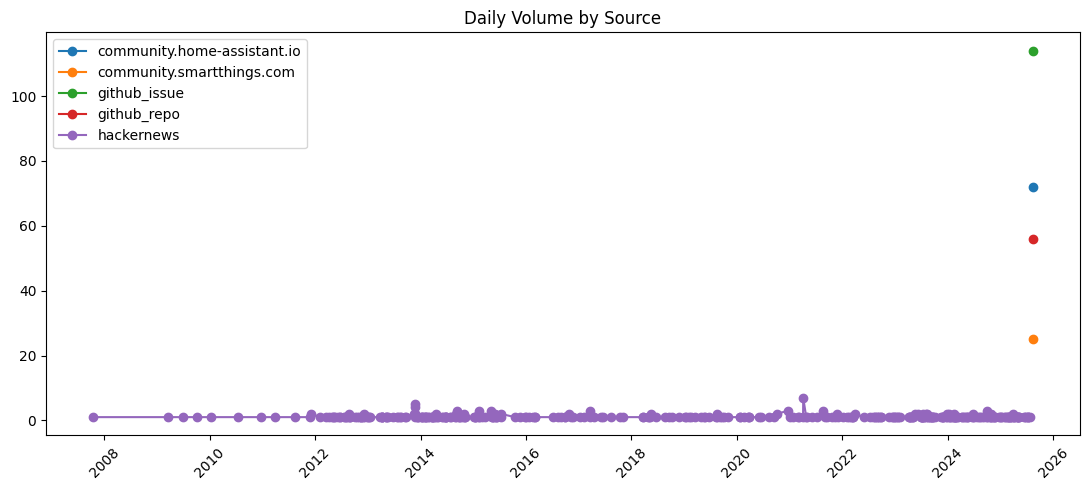

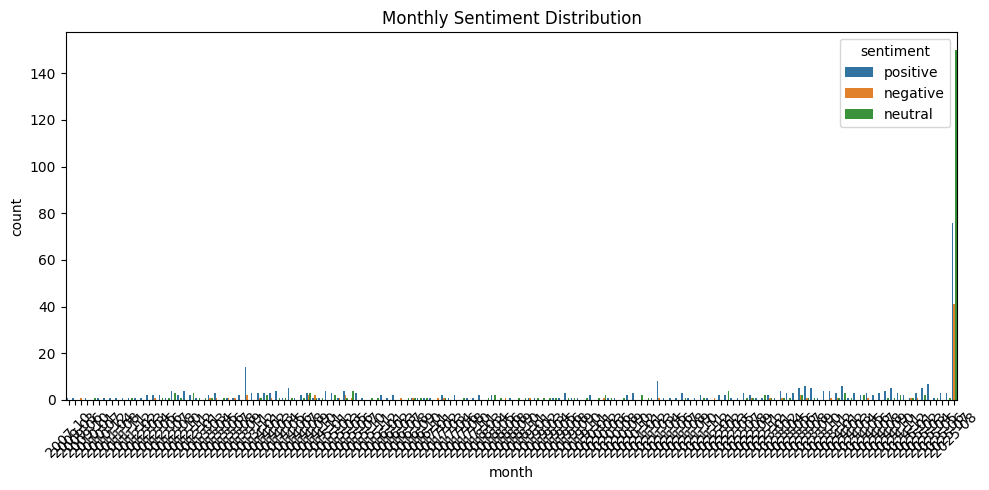

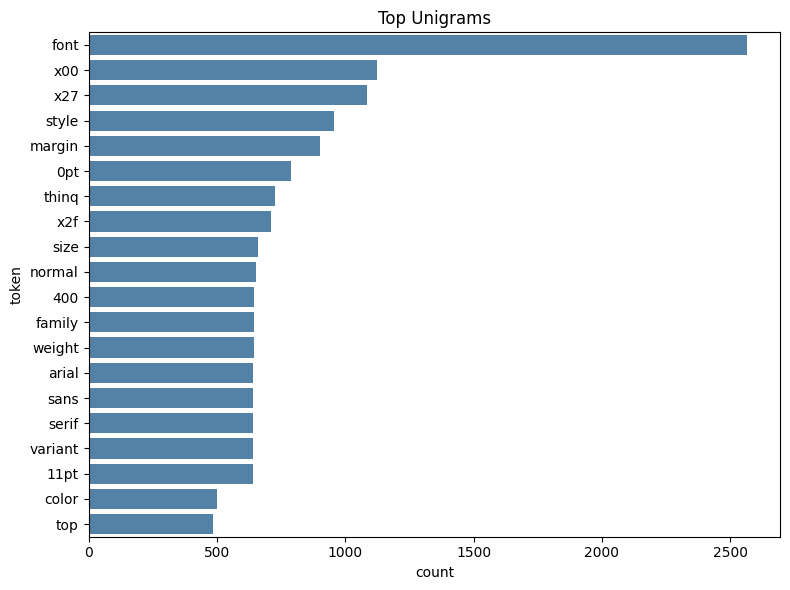

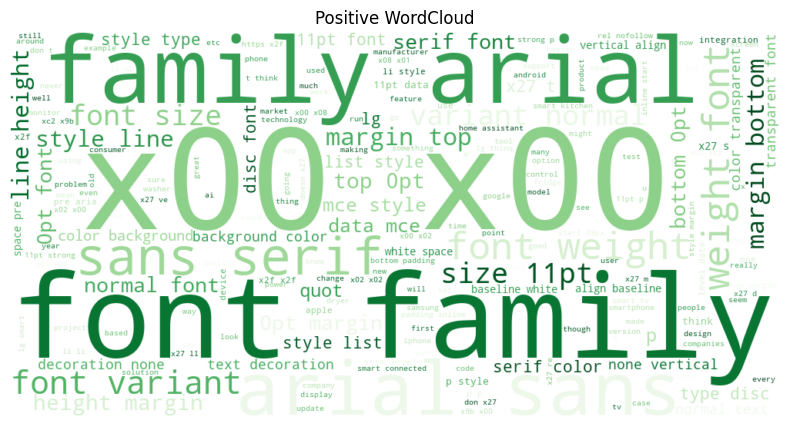

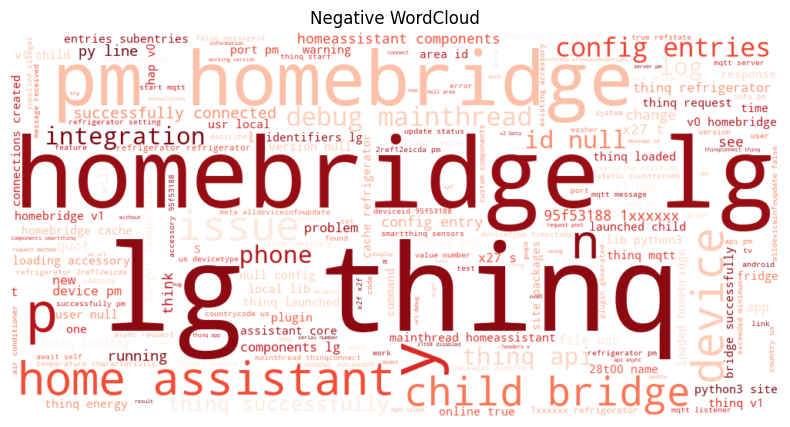

Exported -> data\thinq_multisource\processed\processed.csv


In [7]:
# 20-24 Aspect Extraction, Topic Modeling, Temporal Trends, Visualization, Export
# 20 Aspect / Entity Extraction (simple keywords)
ASPECT_MAP = {
    'washer':['washer','laundry','wash'],
    'fridge':['fridge','refrigerator'],
    'dryer':['dryer'],
    'app':['app','application'],
    'wifi':['wifi','network','wireless'],
    'integration':['integration','integrate','api']
}

def extract_aspects(tokens):
    found=set()
    low_tokens = [t.lower() for t in tokens]
    for aspect, kws in ASPECT_MAP.items():
        if any(k in low_tokens for k in kws):
            found.add(aspect)
    return list(found)

raw_df['aspects'] = raw_df['tokens'].map(extract_aspects)

# Aspect counts
aspect_counts = Counter(itertools.chain.from_iterable(raw_df['aspects']))
print('Aspect counts:', aspect_counts)

# 21 Topic Modeling (basic LDA)
TOPIC_K = 5
texts = raw_df['cleaned'].tolist()
vectorizer = TfidfVectorizer(max_df=0.9, min_df=2, ngram_range=(1,2))
X = vectorizer.fit_transform(texts)
if X.shape[0] >= TOPIC_K and X.shape[1] > 0:
    lda = LatentDirichletAllocation(n_components=TOPIC_K, random_state=42, learning_method='online')
    lda_topics = lda.fit_transform(X)
    raw_df['topic'] = lda_topics.argmax(axis=1)
    feat_names = np.array(vectorizer.get_feature_names_out())
    topic_terms = {}
    for k, comp in enumerate(lda.components_):
        top_idx = comp.argsort()[-10:][::-1]
        topic_terms[k] = feat_names[top_idx].tolist()
    print('LDA topic terms:', topic_terms)
else:
    raw_df['topic'] = -1
    topic_terms = {}
    print('Not enough data for LDA; topics set to -1')

# 22 Temporal Trend Analysis
if 'date' in raw_df:
    vol = raw_df.groupby(['date','source']).size().reset_index(name='count')
    if not vol.empty:
        plt.figure(figsize=(11,5))
        for src, subdf in vol.groupby('source'):
            plt.plot(subdf['date'], subdf['count'], marker='o', label=src)
        plt.xticks(rotation=45); plt.title('Daily Volume by Source'); plt.legend(); plt.tight_layout()
        plt.savefig(ART_DIR/'volume_by_source.png', dpi=140)
        plt.show()

    sent_trend = raw_df.groupby(['month','sentiment']).size().reset_index(name='count') if 'month' in raw_df else pd.DataFrame()
    if not sent_trend.empty:
        plt.figure(figsize=(10,5))
        sns.barplot(data=sent_trend, x='month', y='count', hue='sentiment')
        plt.title('Monthly Sentiment Distribution'); plt.xticks(rotation=45)
        plt.tight_layout(); plt.savefig(ART_DIR/'monthly_sentiment.png', dpi=140); plt.show()

# 23 Visualization (Frequency & WordCloud)
plt.figure(figsize=(8,6))
sns.barplot(data=uni_df.head(20), x='count', y='token', color='steelblue')
plt.title('Top Unigrams'); plt.tight_layout(); plt.savefig(ART_DIR/'top_unigrams.png', dpi=140); plt.show()

for label in ['positive','negative']:
    subset = raw_df.loc[raw_df.sentiment==label,'cleaned']
    if subset.empty: continue
    txt = ' '.join(subset)
    wc = WordCloud(width=1000,height=500, background_color='white', colormap='Greens' if label=='positive' else 'Reds').generate(txt)
    plt.figure(figsize=(12,5)); plt.imshow(wc, interpolation='bilinear'); plt.axis('off'); plt.title(f'{label.title()} WordCloud')
    plt.savefig(ART_DIR/f'{label}_wordcloud.png', dpi=140, bbox_inches='tight'); plt.show()

# 24 Export Artifacts
raw_path = RAW_DIR/'combined_raw.csv'
proc_path = PROC_DIR/'processed.csv'
raw_df.to_csv(proc_path, index=False, encoding='utf-8-sig')
with open(PROC_DIR/'topic_terms.json','w', encoding='utf-8') as f: json.dump(topic_terms, f, ensure_ascii=False)

print('Exported ->', proc_path)

In [8]:
# 25-27 Incremental Update, Basic Tests, Cache Controls
# 25 Incremental Update Logic (simplified)
HISTORY_PATH = PROC_DIR/'processed.csv'
if HISTORY_PATH.exists():
    old = pd.read_csv(HISTORY_PATH)
    prev_max = old['created_utc'].max() if 'created_utc' in old else 0
    new_part = raw_df[raw_df['created_utc']>prev_max]
    merged = pd.concat([old, new_part], ignore_index=True)
    merged.drop_duplicates('combined_text', inplace=True)
    merged.to_csv(HISTORY_PATH, index=False, encoding='utf-8-sig')
    print('Incremental update: +', len(new_part), ' -> total', len(merged))
else:
    raw_df.to_csv(HISTORY_PATH, index=False, encoding='utf-8-sig')
    print('Initial save', len(raw_df))

# 26 Basic Tests
assert 'cleaned' in raw_df, 'cleaned column missing'
assert raw_df['cleaned'].str.len().ge(0).all(), 'clean length negative?!'
assert raw_df['sentiment'].isin(['positive','neutral','negative']).all(), 'invalid sentiment label'
print('Basic tests passed.')

# 27 Cache Invalidation & Controls
FORCE_REFRESH = False  # if True, ignore local cache
if FORCE_REFRESH:
    requests_cache.clear()
    print('Cache cleared (FORCE_REFRESH)')
else:
    print('Cache retained')

print('Notebook pipeline complete.')

Incremental update: + 0  -> total 671
Basic tests passed.
Cache retained
Notebook pipeline complete.
